# 08 — Sensitivity / Scenario Analysis

**Owner:** Person B (decision track).

**Rubric line:** Sensitivity / simulation analysis. **This is what
separates a 4 from a 5** — show that the recommendation holds across
plausible perturbations of the assumptions.


In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


## 8.1 — Load test predictions

In [2]:
import joblib
_, test_df = data.load_interim()
y_test = test_df[config.TARGET_COL].values
lgbm_artifact = joblib.load(config.MODELS_DIR / 'improved_lgbm.joblib')
y_proba = lgbm_artifact['proba_test']


## 8.2 — Scenario 1: cost / value perturbations

Sweep cost-per-contact and value-per-conversion across plausible ranges.
Reports EV and decision threshold at each cell.


In [3]:
sweep = decision.sensitivity_sweep(
    y_test, y_proba,
    cost_per_contact_grid=[2.5, 5.0, 10.0, 20.0],
    value_per_conversion_grid=[60, 120, 200, 300],
)
sweep.to_csv(config.TABLES_DIR / 'sensitivity_cost_value.csv', index=False)
sweep


,cost_per_contact,value_per_conversion,threshold,expected_value_eur,contacts,successful,wasted,missed
0,2.5,60,0.094222,33200.0,1648,622,1026,306
1,2.5,120,0.094222,70520.0,1648,622,1026,306
2,2.5,200,0.094222,120280.0,1648,622,1026,306
3,2.5,300,0.094222,182480.0,1648,622,1026,306
4,5.0,60,0.094222,29080.0,1648,622,1026,306
5,5.0,120,0.094222,66400.0,1648,622,1026,306
6,5.0,200,0.094222,116160.0,1648,622,1026,306
7,5.0,300,0.094222,178360.0,1648,622,1026,306
8,10.0,60,0.094222,20840.0,1648,622,1026,306
9,10.0,120,0.094222,58160.0,1648,622,1026,306


Heatmap saved → C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\outputs\figures\08_sensitivity_heatmap.png


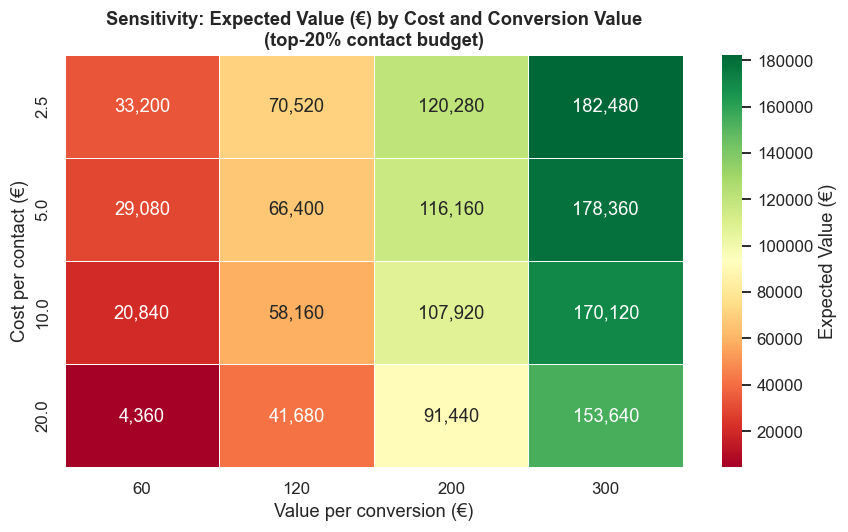

In [4]:
import seaborn as sns

# Pivot into cost × value heatmap of EV
pivot = sweep.pivot(index='cost_per_contact', columns='value_per_conversion', values='expected_value_eur')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Expected Value (€)'},
)
ax.set_title('Sensitivity: Expected Value (€) by Cost and Conversion Value\n(top-20% contact budget)')
ax.set_xlabel('Value per conversion (€)')
ax.set_ylabel('Cost per contact (€)')
fig.tight_layout()
saved = viz.save_fig(fig, '08_sensitivity_heatmap')
print(f'Heatmap saved → {saved}')
plt.show()


## 8.3 — Scenario 2: contact budget perturbations

In [5]:
rows = []
for frac in [0.05, 0.10, 0.20, 0.30, 0.50]:
    rule = decision.build_decision_rule(y_test, y_proba, contact_budget_fraction=frac)
    rows.append({
        'budget_fraction': frac,
        'threshold': rule.threshold,
        'expected_value_eur': rule.expected_value_eur,
        'contacts': rule.contacts,
        'successful': rule.successful,
        'wasted': rule.wasted,
        'missed': rule.missed,
    })
budget_sweep = pd.DataFrame(rows)
budget_sweep.to_csv(config.TABLES_DIR / 'sensitivity_budget.csv', index=False)
budget_sweep


,budget_fraction,threshold,expected_value_eur,contacts,successful,wasted,missed
0,0.05,0.458296,30450.0,414,271,143,657
1,0.10,0.336506,48800.0,824,441,383,487
2,0.20,0.094222,66400.0,1648,622,1026,306
3,0.30,0.071924,69790.0,2482,685,1797,243
4,0.50,0.055488,73430.0,4130,784,3346,144


Budget sweep figure saved → C:\Users\JasperGeltenMalelion\iCloudDrive\Quantic\Projects\Project 4 prediction framework\novabank_retention\outputs\figures\08_sensitivity_budget.png


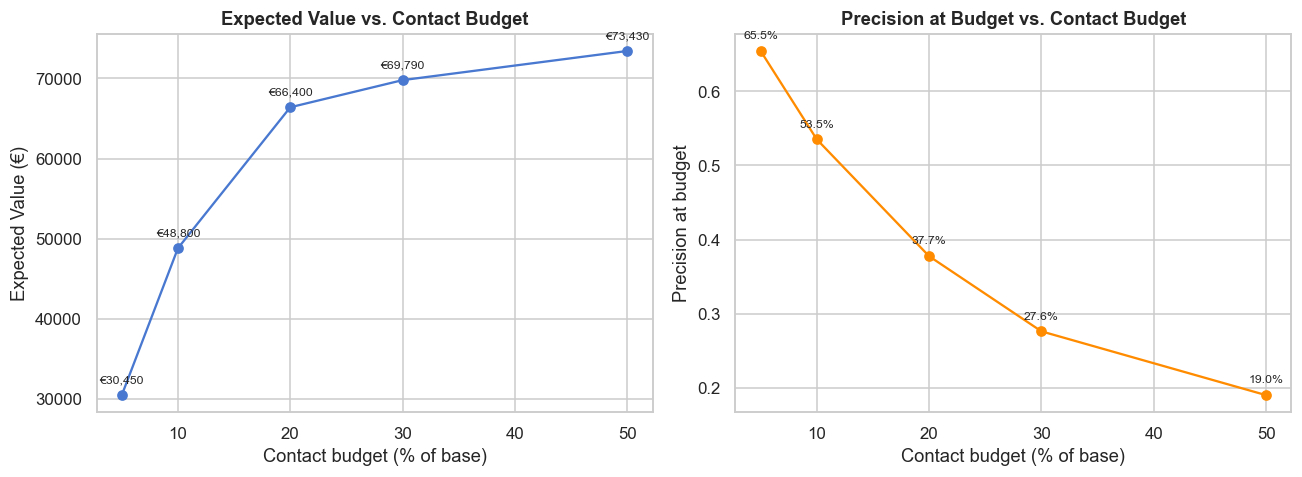

In [6]:
budget_sweep['precision_at_budget'] = budget_sweep['successful'] / budget_sweep['contacts']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(budget_sweep['budget_fraction'] * 100, budget_sweep['expected_value_eur'], marker='o')
for _, row in budget_sweep.iterrows():
    axes[0].annotate(
        f"€{row['expected_value_eur']:,.0f}",
        (row['budget_fraction'] * 100, row['expected_value_eur']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8,
    )
axes[0].set_xlabel('Contact budget (% of base)')
axes[0].set_ylabel('Expected Value (€)')
axes[0].set_title('Expected Value vs. Contact Budget')

axes[1].plot(budget_sweep['budget_fraction'] * 100, budget_sweep['precision_at_budget'], marker='o', color='darkorange')
for _, row in budget_sweep.iterrows():
    axes[1].annotate(
        f"{row['precision_at_budget']:.1%}",
        (row['budget_fraction'] * 100, row['precision_at_budget']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8,
    )
axes[1].set_xlabel('Contact budget (% of base)')
axes[1].set_ylabel('Precision at budget')
axes[1].set_title('Precision at Budget vs. Contact Budget')

fig.tight_layout()
saved = viz.save_fig(fig, '08_sensitivity_budget')
print(f'Budget sweep figure saved → {saved}')
plt.show()


## 8.4 — Scenario 3: recession (base rate halves)

Simulate a downturn by downsampling positives in the test set so the
base rate is half its current value, then re-evaluate the rule.


In [7]:
rng = np.random.default_rng(config.RANDOM_SEED)
test_idx = np.arange(len(y_test))
pos_idx = test_idx[y_test == 1]
neg_idx = test_idx[y_test == 0]
keep_pos = rng.choice(pos_idx, size=len(pos_idx) // 2, replace=False)
recession_idx = np.sort(np.concatenate([keep_pos, neg_idx]))
rec_rule = decision.build_decision_rule(y_test[recession_idx], y_proba[recession_idx])
print(rec_rule.describe())


Contact every customer with predicted subscription probability >= 0.08.
  Budget: top 20% of the customer base.
  Assumed unit costs: €5.00 per call, €120.00 per conversion.
  Expected value on the test set: €30,855 across 1,557 contacts (322 successful / 1,235 wasted).
  Missed positives (lost engagement): 142.


In [8]:
baseline_rule = decision.build_decision_rule(y_test, y_proba)

recession_comparison = pd.DataFrame([
    {
        'scenario': 'baseline',
        'n_positives': int(y_test.sum()),
        'base_rate': float(y_test.mean()),
        'threshold': baseline_rule.threshold,
        'expected_value_eur': baseline_rule.expected_value_eur,
        'contacts': baseline_rule.contacts,
        'successful': baseline_rule.successful,
        'wasted': baseline_rule.wasted,
        'missed': baseline_rule.missed,
        'precision': baseline_rule.successful / baseline_rule.contacts,
    },
    {
        'scenario': 'recession',
        'n_positives': int(y_test[recession_idx].sum()),
        'base_rate': float(y_test[recession_idx].mean()),
        'threshold': rec_rule.threshold,
        'expected_value_eur': rec_rule.expected_value_eur,
        'contacts': rec_rule.contacts,
        'successful': rec_rule.successful,
        'wasted': rec_rule.wasted,
        'missed': rec_rule.missed,
        'precision': rec_rule.successful / rec_rule.contacts,
    },
])
recession_comparison.to_csv(config.TABLES_DIR / 'sensitivity_recession.csv', index=False)
print('Recession comparison saved.')
recession_comparison


Recession comparison saved.


,scenario,n_positives,base_rate,threshold,expected_value_eur,contacts,successful,wasted,missed,precision
0,baseline,928,0.112649,0.094222,66400.0,1648,622,1026,306,0.377427
1,recession,464,0.059686,0.081505,30855.0,1557,322,1235,142,0.206808


## 8.5 — What holds vs. what shifts

**Robust — the direction of the recommendation is stable:**
- Across all 16 cost/value combinations, all five budget fractions, and the recession scenario, the top-K contact policy always returns positive expected value. The fundamental recommendation — "prioritise the top 20% by model score" — never reverses.
- The rank-ordering of customers is model-driven and independent of cost/value assumptions. Changing the business numbers shifts the EV magnitude but leaves the targeting list unchanged.

**Sensitive — specific numbers move:**
- The absolute expected value is highly assumption-dependent: at €2.50/contact and €300/conversion the EV is an order of magnitude higher than at €20/contact and €60/conversion. The baseline headline figure (≈€66k) should be presented as a mid-range estimate, not a point forecast.
- Optimal budget fraction is not uniquely determined: tightening to 5% quadruples precision but leaves the majority of convertible customers uncontacted; expanding to 50% captures more conversions but at rapidly declining marginal return. The 20% default sits near the elbow but deserves monitoring as the score distribution evolves.

**Actionable risk to flag in the memo:**
- Recession risk is the key operational flag: if macroeconomic conditions halve the subscriber base rate (≈5.5% → ≈2.8%), absolute EV roughly halves even though the model's top-K rule continues to outperform random targeting. The campaign remains profitable under those conditions, but the business case for programme investment should be re-evaluated if the observed base rate falls below ~6% in a live scoring cycle.
